In [7]:
#Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB
None
       completion_rate  avg_score_im

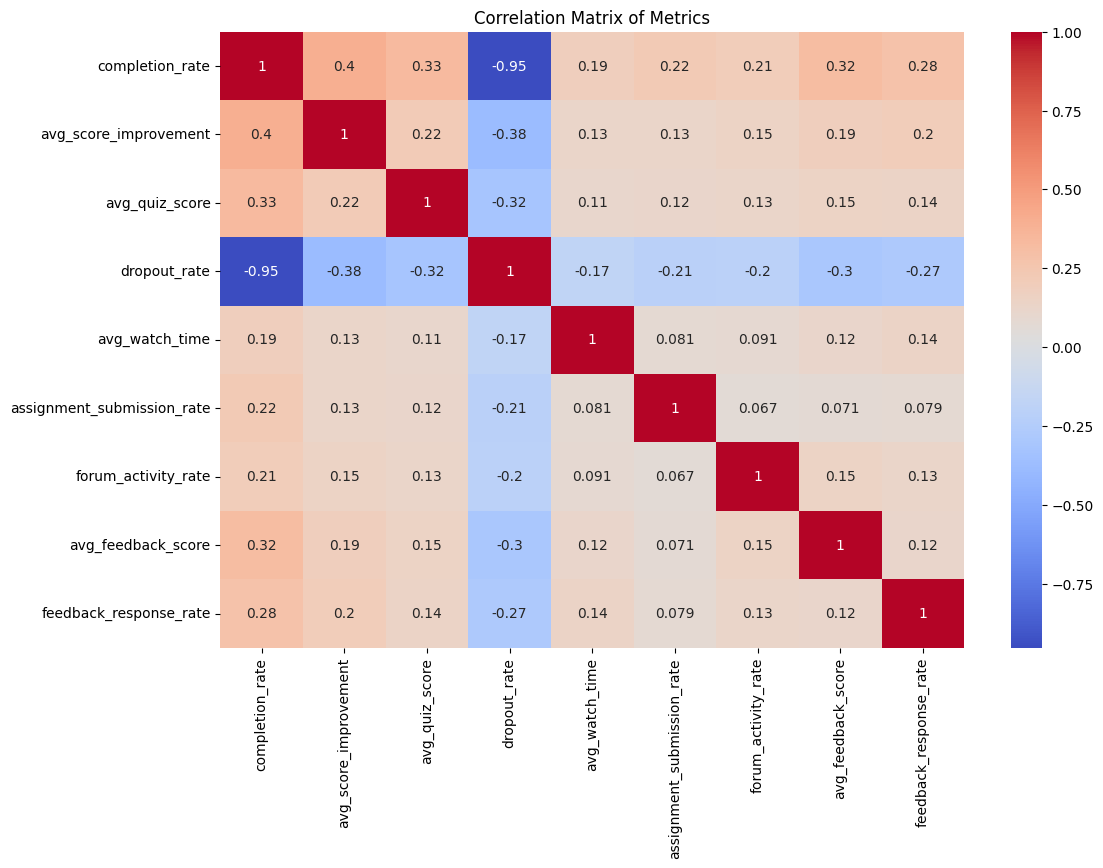

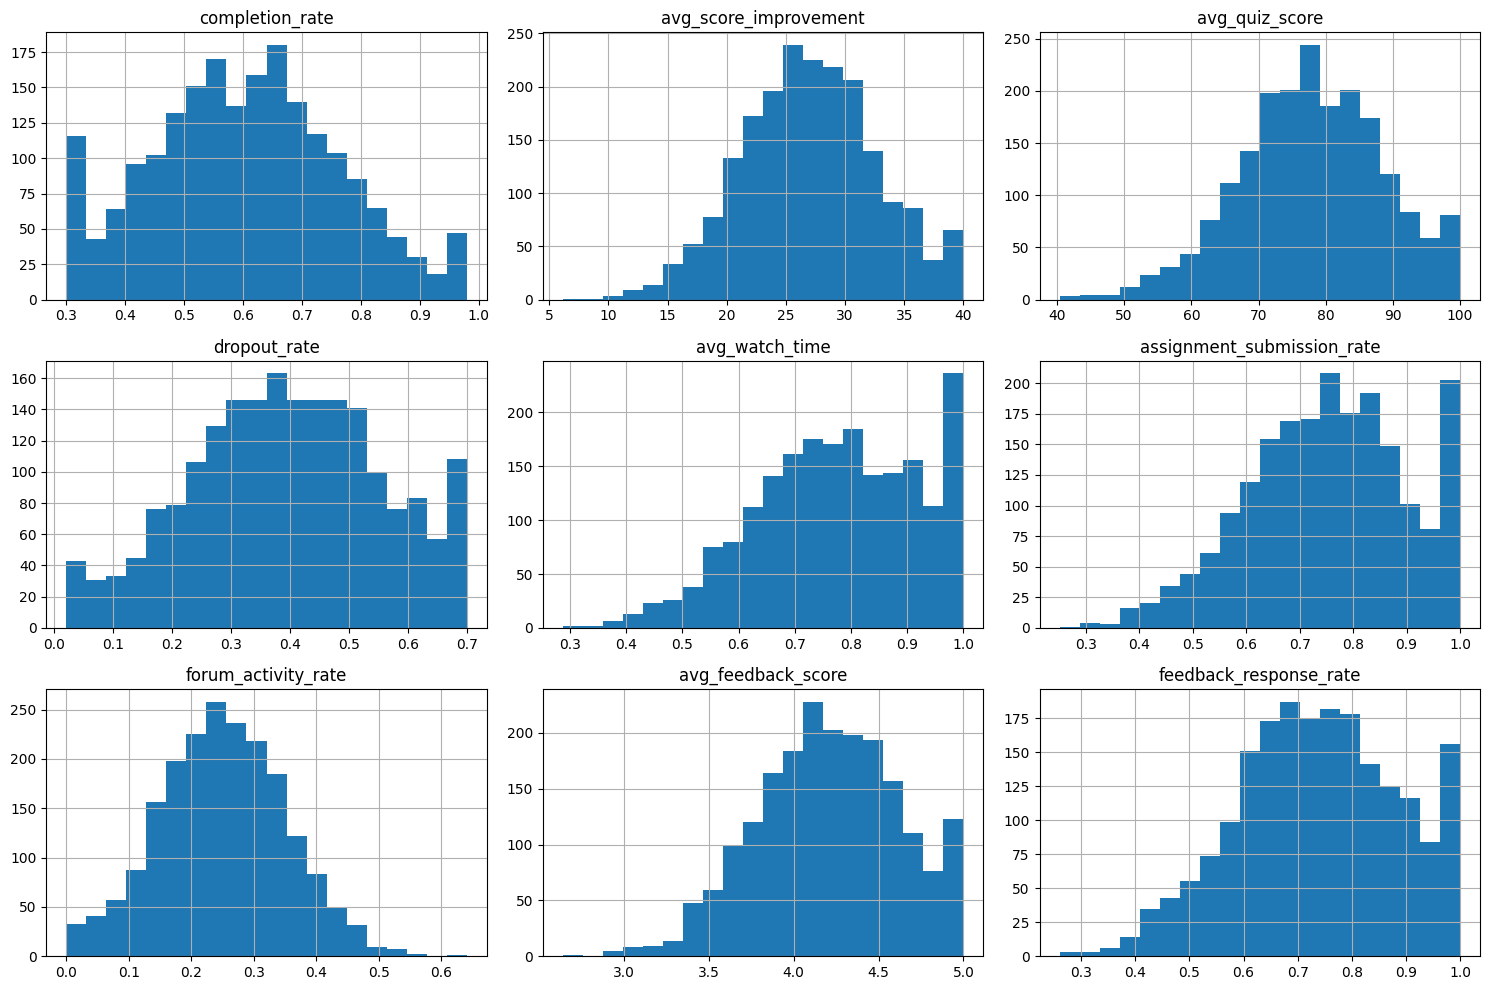

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv')

print(df.info())
print(df.describe())

plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(['batch_id', 'instructor_id', 'course_id'], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Metrics")
plt.show()

df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

In [8]:
#Defining Instructor Effectiveness

In [3]:
df['normalized_feedback'] = (df['avg_feedback_score'] - 1) / 4
df['outcome_score'] = (df['completion_rate'] + (df['avg_quiz_score'] / 100)) / 2
df['engagement_score'] = (df['avg_watch_time'] + df['assignment_submission_rate']) / 2

df['batch_effectiveness_score'] = (
    (df['outcome_score'] * 0.4) + 
    (df['engagement_score'] * 0.3) + 
    (df['normalized_feedback'] * 0.3)
) * 100

instructor_data = df.groupby('instructor_id').agg({
    'batch_effectiveness_score': 'mean',
    'batch_id': 'count',
    'completion_rate': 'mean',
    'avg_quiz_score': 'mean',
    'avg_watch_time': 'mean',
    'assignment_submission_rate': 'mean',
    'avg_feedback_score': 'mean'
}).rename(columns={'batch_id': 'total_batches_taught'})

def get_tier(score):
    if score >= 75:
        return 'High'
    elif score >= 50:
        return 'Medium'
    else:
        return 'Low'

instructor_data['effectiveness_tier'] = instructor_data['batch_effectiveness_score'].apply(get_tier)

print(instructor_data['effectiveness_tier'].value_counts())
print(instructor_data.head())

effectiveness_tier
Medium    64
High      56
Name: count, dtype: int64
               batch_effectiveness_score  total_batches_taught  \
instructor_id                                                    
I_001                          73.191944                    25   
I_002                          80.214240                    20   
I_003                          81.533087                    18   
I_004                          71.047405                    17   
I_005                          84.238960                    19   

               completion_rate  avg_quiz_score  avg_watch_time  \
instructor_id                                                    
I_001                 0.543887       78.900194        0.766513   
I_002                 0.730874       81.737198        0.837393   
I_003                 0.768447       81.590928        0.818441   
I_004                 0.458328       77.680317        0.793130   
I_005                 0.859747       85.828159        0.847026   

   

In [ ]:
#Machine Learning Model Development

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

X = instructor_data.drop(['batch_effectiveness_score', 'effectiveness_tier'], axis=1)
y = instructor_data['effectiveness_tier']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [10]:
#Model Evaluation

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        11
      Medium       1.00      1.00      1.00        13

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



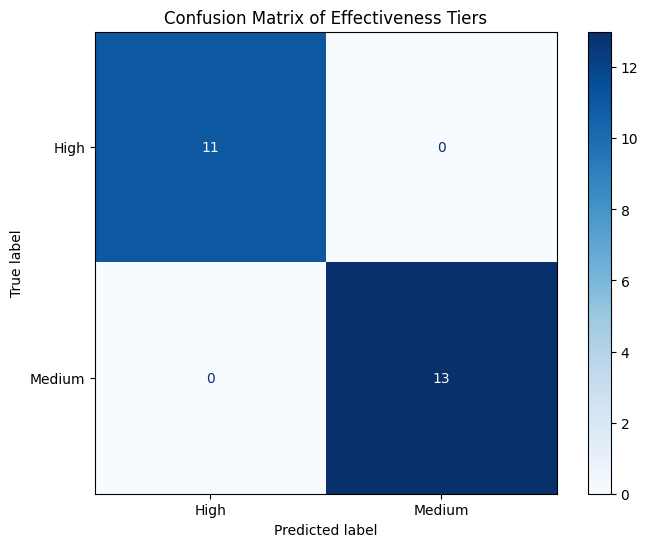

In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=le.classes_, cmap='Blues', ax=plt.gca())
plt.title("Confusion Matrix of Effectiveness Tiers")
plt.show()

In [ ]:
#Interpretation & Mandatory Analysis Questions

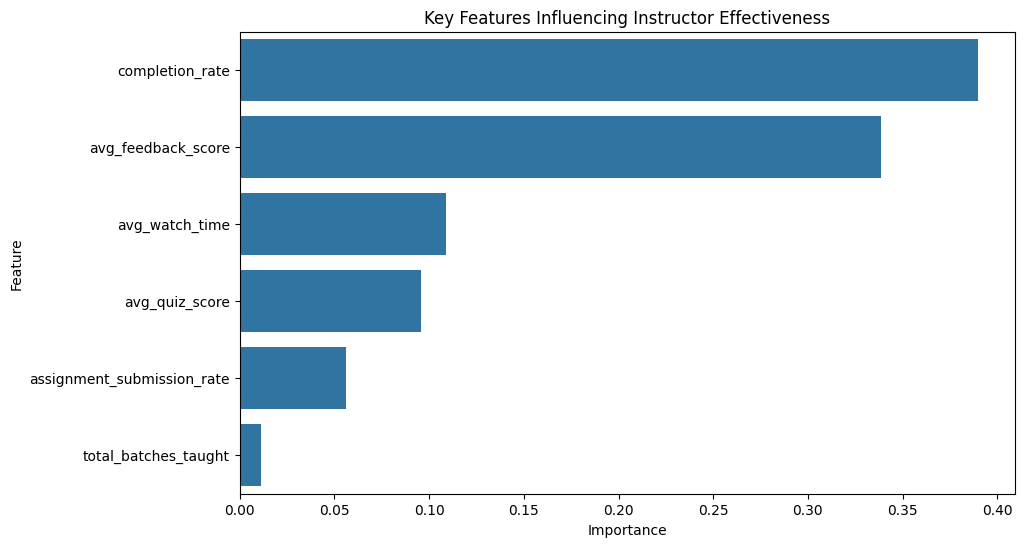

                      Feature  Importance
1             completion_rate    0.389739
5          avg_feedback_score    0.338426
3              avg_watch_time    0.109073
2              avg_quiz_score    0.095524
4  assignment_submission_rate    0.056146
0        total_batches_taught    0.011092


In [6]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Key Features Influencing Instructor Effectiveness")
plt.show()

print(feature_importance_df)